<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_2_LogisticRegression/18_2_2_LogReg_Interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Logistic Regression
## Interpretability — When the Model Must Explain Itself

**Author:** Brad Sheese

---

## Introduction

In Notebook 18_2_1 we built a logistic regression model on the Titanic dataset and read off odds ratios from the fitted coefficients. In this notebook we go deeper: we ask how *confident* we are in those odds ratios, compare what logistic regression and XGBoost each let us say about their predictions, and build the case for when interpretability is not a preference but a requirement.

### Learning Objectives

1. Compute and visualize **confidence intervals** on logistic regression odds ratios using `statsmodels`.
2. Train XGBoost on the same data and contrast its feature importance with LR's signed odds ratios.
3. Understand the difference between **magnitude** (which features matter) and **direction + magnitude** (how and how much each feature moves the prediction).
4. Articulate the regulatory and practical contexts where interpretability is required.

## Setup: Same Data, Two Models

We will use the same Titanic dataset and feature engineering from Notebook 18_2_1, then fit both a logistic regression and an XGBoost model. The goal is a fair comparison: identical data, identical features, two different models, and the question of what each one lets us say.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import statsmodels.api as sm
import xgboost as xgb

sns.set_theme(style='whitegrid')

### Load and Prepare the Data

In [2]:
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_titanic.csv'
df = pd.read_csv(url)
df.columns = df.columns.str.lower().str.replace(' aboard', '', regex=False)

# Feature engineering (identical to Notebook 18_2_1)
df['sibspouse']   = (df['siblings/spouses'] > 0).astype(int)
df['parentchild'] = (df['parents/children'] > 0).astype(int)
df['sex_f']       = (df['sex'] == 'female').astype(int)   # 1=female, 0=male
df['fare_log']    = np.log1p(df['fare'])
df = pd.get_dummies(df, columns=['pclass'], prefix='pclass', drop_first=True)

# Ensure all dummy columns are int (newer pandas returns bool from get_dummies)
for col in ['pclass_2', 'pclass_3']:
    df[col] = df[col].astype(int)

features = ['age', 'sibspouse', 'parentchild', 'fare_log', 'sex_f', 'pclass_2', 'pclass_3']
X = df[features]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples   Test: {X_test.shape[0]} samples')

Train: 665 samples   Test: 222 samples


### Train the Sklearn Logistic Regression

We use the sklearn pipeline for performance metrics — it handles scaling cleanly and integrates with cross-validation. We will use `statsmodels` separately in Section 2 for the statistical output (confidence intervals, p-values) that sklearn does not provide.

In [3]:
numeric_features = ['age', 'fare_log']
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'
)
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)

lr_auc = roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1])
lr_acc = lr_pipeline.score(X_test, y_test)
print(f'Logistic Regression — Accuracy: {lr_acc:.3f}   AUC: {lr_auc:.3f}')

Logistic Regression — Accuracy: 0.770   AUC: 0.842


### Train XGBoost on the Same Features

XGBoost does not require scaling and handles the features directly. We use the same train/test split so the comparison is fair.

In [4]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    eval_metric='logloss', random_state=42, enable_categorical=False
)
# XGBoost works directly on the unscaled features
xgb_model.fit(X_train, y_train)

xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
xgb_acc = xgb_model.score(X_test, y_test)
print(f'XGBoost          — Accuracy: {xgb_acc:.3f}   AUC: {xgb_auc:.3f}')
print()
print('Both models achieve similar performance on this dataset.')
print('The question is: what can each model tell us about *why* it made its predictions?')

XGBoost          — Accuracy: 0.797   AUC: 0.846

Both models achieve similar performance on this dataset.
The question is: what can each model tell us about *why* it made its predictions?


---

## Section 1: Confidence Intervals on Odds Ratios

### Why Statsmodels Instead of Sklearn?

Sklearn's `LogisticRegression` is designed for prediction. It fits fast, integrates with pipelines, and works well with cross-validation. But it does not compute standard errors, p-values, or confidence intervals on coefficients — it has no concept of statistical uncertainty.

`statsmodels` is a statistics library: it fits the same logistic regression model but treats it as a statistical estimator. It gives you:
- **Standard errors** on each coefficient
- **p-values** testing whether each coefficient is significantly different from zero
- **Confidence intervals** — the range of coefficient values consistent with the data

We need to scale the features manually before passing them to statsmodels, since it does not have a pipeline concept.

> **One subtlety before you compare numbers:** sklearn's `LogisticRegression` applies L2 regularization by default, which shrinks coefficients slightly toward zero. Statsmodels fits the *unpenalized* model. That is why the odds ratios below (e.g., `sex_f` ≈ 15) differ modestly from the sklearn values in Notebook 18_2_1 (`sex` ≈ 12). Same data, same model family — one is shrunk, the other is not.

In [5]:
# Scale the continuous features manually for statsmodels
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[['age', 'fare_log']] = scaler.fit_transform(X_train[['age', 'fare_log']])
X_test_scaled[['age', 'fare_log']]  = scaler.transform(X_test[['age', 'fare_log']])

# Statsmodels requires an explicit intercept column
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm  = sm.add_constant(X_test_scaled)

sm_model = sm.Logit(y_train, X_train_sm).fit(disp=0)
print(sm_model.summary2().tables[1].round(3))

             Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const       -0.022     0.273  -0.081  0.936  -0.558   0.514
age         -0.600     0.127  -4.714  0.000  -0.849  -0.350
sibspouse   -0.456     0.259  -1.762  0.078  -0.964   0.051
parentchild -0.242     0.279  -0.865  0.387  -0.789   0.306
fare_log     0.230     0.171   1.343  0.179  -0.106   0.567
sex_f        2.680     0.226  11.842  0.000   2.237   3.124
pclass_2    -0.976     0.359  -2.714  0.007  -1.680  -0.271
pclass_3    -2.178     0.400  -5.450  0.000  -2.961  -1.395


### Reading the Output

Each row is one feature. The columns you care about most:

| Column | Meaning |
|---|---|
| `Coef.` | The log-odds coefficient (same as sklearn's `coef_`) |
| `Std.Err.` | Uncertainty in the estimate |
| `P>\|z\|` | p-value: probability of seeing this coefficient if the true effect is zero |
| `[0.025` `0.975]` | 95% confidence interval on the coefficient |

**Key question:** Are the confidence intervals tight or wide? A wide CI means the data are consistent with a large range of effects — the estimate is uncertain. A narrow CI means the data are informative about this feature's effect.

We will convert all of these to odds ratios in the next cell.

In [6]:
# Extract coefficients and 95% CIs, convert to odds ratios
conf_int = sm_model.conf_int(alpha=0.05)
conf_int.columns = ['ci_low', 'ci_high']

or_df = pd.DataFrame({
    'feature'  : sm_model.params.index,
    'log_odds' : sm_model.params.values,
    'p_value'  : sm_model.pvalues.values,
    'OR'       : np.exp(sm_model.params.values),
    'OR_low'   : np.exp(conf_int['ci_low'].values),
    'OR_high'  : np.exp(conf_int['ci_high'].values),
})
or_df = or_df[or_df['feature'] != 'const'].copy()
or_df['significant'] = or_df['p_value'] < 0.05
or_df = or_df.sort_values('OR', ascending=False).reset_index(drop=True)
print(or_df[['feature', 'OR', 'OR_low', 'OR_high', 'p_value', 'significant']].round(3).to_string())

       feature      OR  OR_low  OR_high  p_value  significant
0        sex_f  14.587   9.361   22.731    0.000         True
1     fare_log   1.259   0.900    1.762    0.179        False
2  parentchild   0.785   0.454    1.358    0.387        False
3    sibspouse   0.634   0.381    1.053    0.078        False
4          age   0.549   0.428    0.704    0.000         True
5     pclass_2   0.377   0.186    0.763    0.007         True
6     pclass_3   0.113   0.052    0.248    0.000         True


### Forest Plot: Odds Ratios with Confidence Intervals

A forest plot is the standard visualization for odds ratios. Each point is the estimated OR; the horizontal line is the 95% CI. The vertical line at OR=1 is the reference: features whose CI crosses 1 are not statistically distinguishable from 'no effect.'

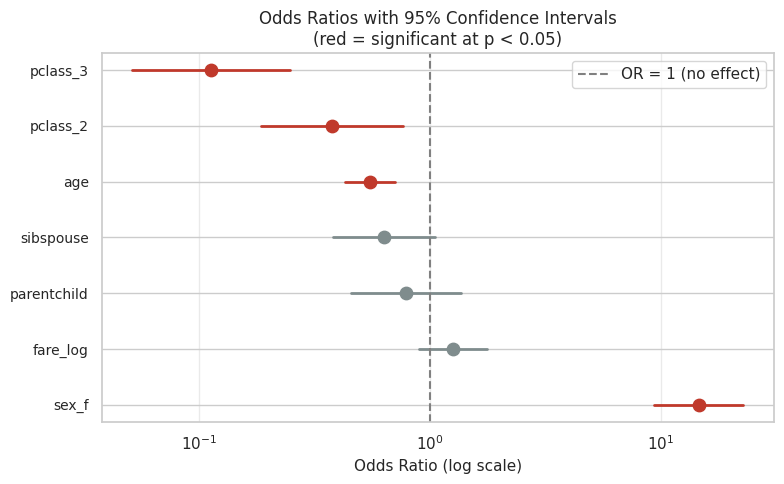

Features with CI crossing OR=1 are not statistically significant.
Note sibspouse and parentchild — wide CIs, likely not significant.


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#c0392b' if s else '#7f8c8d' for s in or_df['significant']]

for i, row in or_df.iterrows():
    ax.plot([row['OR_low'], row['OR_high']], [i, i],
            color=colors[i], lw=2, zorder=2)
    ax.scatter(row['OR'], i, color=colors[i], s=80, zorder=3)

ax.axvline(1, color='gray', linestyle='--', lw=1.5, label='OR = 1 (no effect)')
ax.set_yticks(range(len(or_df)))
ax.set_yticklabels(or_df['feature'], fontsize=10)
ax.set_xlabel('Odds Ratio (log scale)', fontsize=11)
ax.set_title('Odds Ratios with 95% Confidence Intervals\n(red = significant at p < 0.05)', fontsize=12)
ax.set_xscale('log')
ax.legend()
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print('Features with CI crossing OR=1 are not statistically significant.')
print('Note sibspouse and parentchild — wide CIs, likely not significant.')

### What the Forest Plot Tells Us

- **`sex_f`** has a very large OR (far right) with a tight CI — being female strongly and reliably predicts survival. This is the dominant signal.
- **`pclass_3`** has OR < 1 with a tight CI — 3rd class passengers had significantly lower odds of survival than 1st class (the reference). The CI does not cross 1.
- **`sibspouse` and `parentchild`** have wide CIs that cross OR=1. Their estimated effect could be as large as the regression says, or it could be near zero. The data are not informative enough to be confident.

This is something neither sklearn's output nor XGBoost feature importance gives you: a clear signal about *which estimates to trust*.

---

## Section 2: What Each Model Can and Cannot Tell You

Both models scored similarly on accuracy and AUC. Now let's compare what each one actually *says* about the predictions it made.

### XGBoost Feature Importance

XGBoost's built-in importance reports how much each feature contributed to reducing the training loss (gain). It answers: *which features matter?*

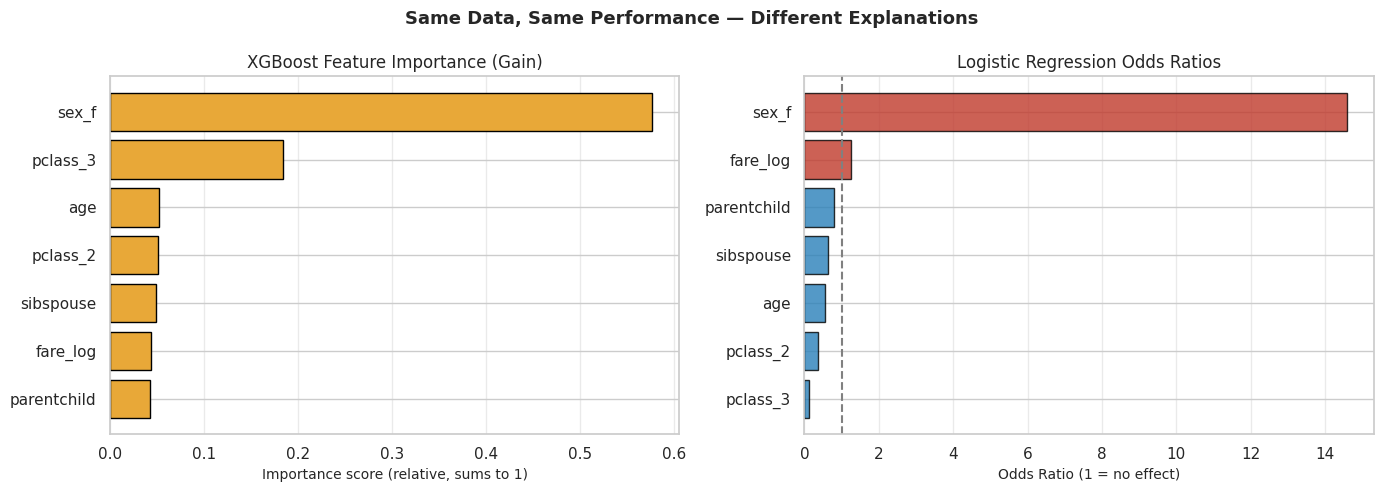

In [8]:
importance_df = pd.DataFrame({
    'feature'   : features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- XGBoost importance (left) ---
axes[0].barh(importance_df['feature'], importance_df['importance'],
             color='#e8a838', edgecolor='black')
axes[0].set_title('XGBoost Feature Importance (Gain)', fontsize=12)
axes[0].set_xlabel('Importance score (relative, sums to 1)', fontsize=10)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.4)

# --- LR odds ratios (right) ---
plot_or = or_df.sort_values('OR')
bar_colors = ['#c0392b' if o > 1 else '#2980b9' for o in plot_or['OR']]
axes[1].barh(plot_or['feature'], plot_or['OR'],
             color=bar_colors, edgecolor='black', alpha=0.8)
axes[1].axvline(1, color='gray', linestyle='--', lw=1.5)
axes[1].set_title('Logistic Regression Odds Ratios', fontsize=12)
axes[1].set_xlabel('Odds Ratio (1 = no effect)', fontsize=10)
axes[1].grid(axis='x', alpha=0.4)

plt.suptitle('Same Data, Same Performance — Different Explanations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Reading the Comparison

Both plots put `sex_f` at the top — both models agree it is the most important feature. But they say very different things beyond that:

**XGBoost tells you:**
- Which features the model used, and roughly how much
- Scores are unsigned and relative — you cannot say whether `fare_log` increases or decreases survival odds, only that it mattered during training
- The score for each feature partially reflects interactions and non-linear effects; the importances are not additive or decomposable

**Logistic regression tells you:**
- Which features matter (same as XGBoost)
- **Direction**: OR > 1 means the feature increases survival odds, OR < 1 decreases them
- **Magnitude**: `sex_f` multiplies odds by ~15; `pclass_3` multiplies odds by ~0.11 (statsmodels fit, as plotted)
- **Uncertainty**: the confidence interval tells you how much to trust each estimate
- **A plain-English statement**: *'Holding all else equal, a female passenger had roughly 15 times higher odds of survival than a male passenger.'*

That last sentence is the kind of statement a regulator, a doctor, or a journalist can understand and audit. XGBoost cannot produce its equivalent.

---

## Section 3: When Interpretability Is Required

### The Regulatory Context

Many high-stakes decisions made by ML models are legally regulated:

- **Credit and lending** (US): Equal Credit Opportunity Act and Fair Credit Reporting Act require adverse action notices — specific reasons a credit application was denied
- **Healthcare** (US/EU): clinical decision support tools face scrutiny from both FDA oversight and clinical ethics; physicians must be able to explain their reasoning
- **GDPR (EU)**: the 'right to explanation' for automated decisions affecting individuals

A black-box model that achieves 2% better AUC is often not a legal option in these domains. Logistic regression — with its signed, statistically validated coefficients — is.

### Individual Prediction Explanation

Because LR is a linear model in log-odds, we can decompose any individual prediction into its feature contributions. The cell below shows this for three test-set passengers.

In [9]:
# Retrieve scaled feature names and coefficients from the sklearn pipeline
feat_names = (
    list(lr_pipeline.named_steps['preprocessor']
         .get_feature_names_out())
)
feat_names = [n.split('__')[-1] for n in feat_names]
coef = lr_pipeline.named_steps['classifier'].coef_[0]
intercept = lr_pipeline.named_steps['classifier'].intercept_[0]

# Transform the test set through the preprocessor
X_test_transformed = lr_pipeline.named_steps['preprocessor'].transform(X_test)

print('Decomposing predictions for three passengers:')
print('-' * 60)
for idx in [0, 5, 12]:
    row = X_test_transformed[idx]
    log_odds = intercept + np.dot(coef, row)
    prob = 1 / (1 + np.exp(-log_odds))
    label = y_test.iloc[idx]
    print(f'\nPassenger {idx} | Actual: {"Survived" if label==1 else "Died"} | '
          f'Predicted P(survive)={prob:.2f}')
    contribs = sorted(zip(feat_names, coef * row),
                      key=lambda x: abs(x[1]), reverse=True)
    for feat, contrib in contribs[:4]:
        direction = '+' if contrib >= 0 else ''
        print(f'  {feat:<15} contribution to log-odds: {direction}{contrib:.3f}')

Decomposing predictions for three passengers:
------------------------------------------------------------

Passenger 0 | Actual: Survived | Predicted P(survive)=0.95
  sex_f           contribution to log-odds: +2.508
  fare_log        contribution to log-odds: +0.572
  age             contribution to log-odds: +0.478
  sibspouse       contribution to log-odds: -0.450

Passenger 5 | Actual: Died | Predicted P(survive)=0.68
  sex_f           contribution to log-odds: +2.508
  pclass_3        contribution to log-odds: -1.785
  age             contribution to log-odds: +0.775
  sibspouse       contribution to log-odds: -0.450

Passenger 12 | Actual: Died | Predicted P(survive)=0.58
  sex_f           contribution to log-odds: +2.508
  pclass_3        contribution to log-odds: -1.785
  fare_log        contribution to log-odds: -0.263
  age             contribution to log-odds: +0.069


### Reading the Decomposition

Each passenger's predicted probability can be traced back to a sum of feature contributions. The intercept is the baseline log-odds (what the model would predict if all scaled features were at their mean). Each feature's contribution is its scaled value times its coefficient.

This decomposition is exactly what a loan officer or doctor needs: *'This patient's high age contributed −0.42 to their log-odds of the positive outcome; their female sex contributed +2.51.'*

A neural network or XGBoost can approximate something similar with post-hoc tools (SHAP values), but for logistic regression it falls out directly from the model — no additional machinery required.

---

## Summary

In this notebook you:

1. Fit the same Titanic data with both **logistic regression** (sklearn + statsmodels) and **XGBoost**, achieving comparable performance.
2. Used `statsmodels` to compute **confidence intervals** on odds ratios — enabling you to distinguish reliable estimates from noisy ones.
3. Built and read a **forest plot**, the standard visualization for communicating odds ratios and their uncertainty to non-technical audiences.
4. Compared what **XGBoost** and **logistic regression** each let you say: XGBoost answers *which features matter*; LR answers *how much, in which direction, and how confident are we*.
5. Demonstrated **individual prediction decomposition**: tracing any single prediction back to its feature contributions — the kind of explanation required by regulators.

**Up next:** Notebook 18_2_3 zooms out to show where logistic regression fits in the history of machine learning — and why understanding it is the foundation for understanding neural networks.

---

## Problems

### Problem 1: Statsmodels vs. Sklearn
We used sklearn for the performance pipeline and statsmodels for the statistical output. Why can't we just use statsmodels for everything? What does sklearn's pipeline provide that statsmodels does not?

*Write your answer here.*

### Problem 2: Interpret a Coefficient
The odds ratio for `pclass_3` is approximately 0.11 with a 95% CI of roughly [0.05, 0.25]. Write two sentences: one interpreting the point estimate, one interpreting what the confidence interval adds to your understanding.

*Write your answer here.*

### Problem 3: The Calibration Claim
This notebook claims that logistic regression produces 'well-calibrated probabilities.' Design a simple test you could run in Python to check whether the Titanic model's predicted probabilities are well-calibrated. What would you plot, and what would a well-calibrated model look like on that plot?

*(Hint: sklearn has a `CalibrationDisplay` in `sklearn.calibration`.)*

*Write your answer here.*

### Problem 4: Your Own Dataset
Pick one of the datasets from Module 18_1 (German Credit or the Adult Census dataset). Fit a logistic regression model and produce a forest plot of the odds ratios with 95% confidence intervals. Which features are statistically significant? Write two sentences interpreting your most surprising finding.

In [10]:
# Your code here


*Write your interpretation here.*